In [49]:
pip install matplotlib seaborn 


Note: you may need to restart the kernel to use updated packages.


In [50]:
pip install plotly scipy

Note: you may need to restart the kernel to use updated packages.


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

In [52]:
df=pd.read_csv(r'D:\Programming\Cognifyz\ML\Restraunt_Pred\data\unprocessed\Dataset .csv')
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


Mean Aggregate Rating: 2.6663700136111403
Median Aggregate Rating: 3.2
Standard Deviation of Aggregate Rating: 1.5163775396521326
Q1: 2.5, Q3: 3.7, IQR: 1.2000000000000002
Lower Bound: 0.6999999999999997, Upper Bound: 5.5
Number of outliers below lower bound: 2148
Number of outliers above upper bound: 0


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Violin Plot of Aggregate Ratings')

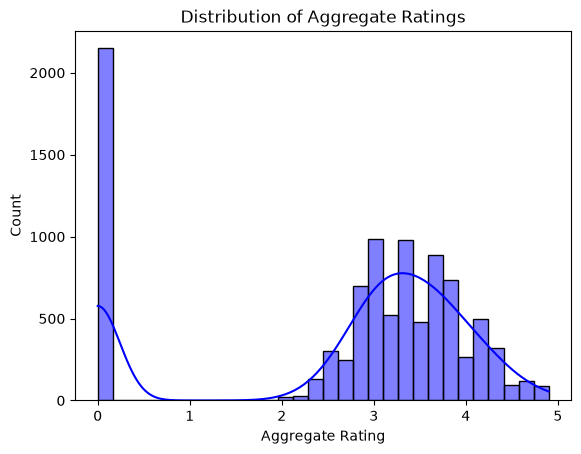

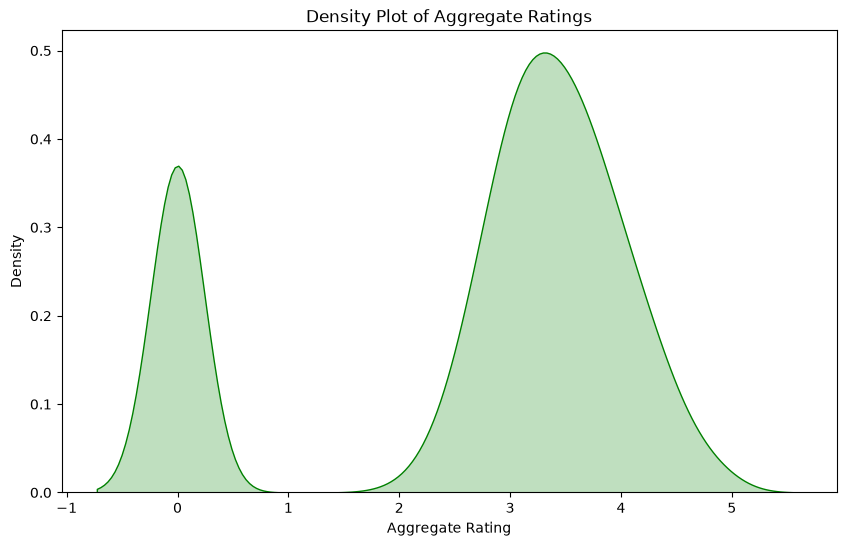

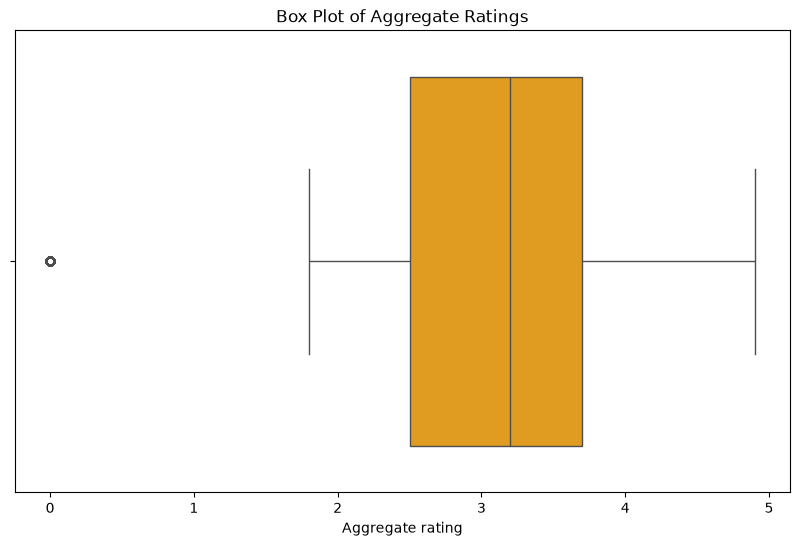

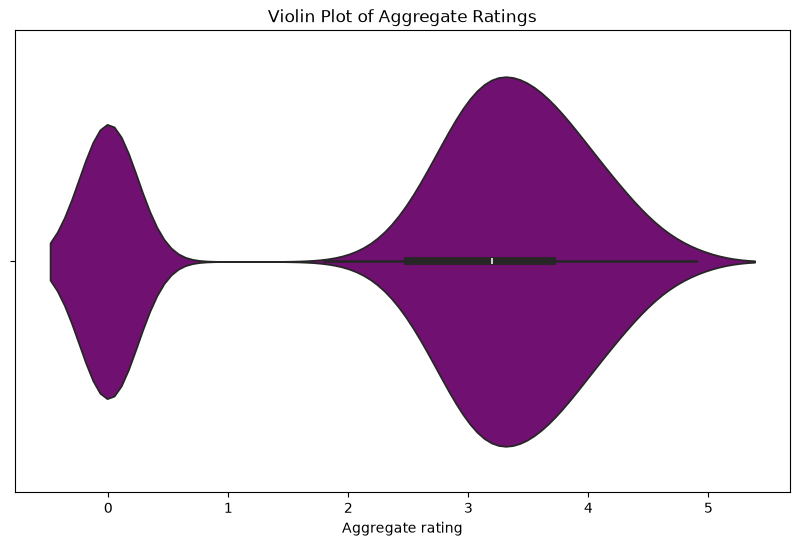

In [53]:
# "Aggregate Rating"-Univariate Analysis

mean_rating = df['Aggregate rating'].mean()
median_rating = df['Aggregate rating'].median()
std_rating = df['Aggregate rating'].std()

print(f"Mean Aggregate Rating: {mean_rating}")
print(f"Median Aggregate Rating: {median_rating}")
print(f"Standard Deviation of Aggregate Rating: {std_rating}")

# outlier using IQR method
Q1 = df['Aggregate rating'].quantile(0.25)
Q3 = df['Aggregate rating'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

# outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of outliers below lower bound: {(df['Aggregate rating'] < lower_bound).sum()}")
print(f"Number of outliers above upper bound: {(df['Aggregate rating'] > upper_bound).sum()}")

# outlier detection using Z-score method
z_scores= np.abs(stats.zscore(df['Aggregate rating']))
z_threshold = 3
outliers_z = np.where(z_scores > z_threshold)



#Distribution Plot
plt.figure(figsize=(10,6))
plt.show()
sns.histplot(df['Aggregate rating'], bins=30, kde=True, color='blue')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')

# Density/KDE plot
plt.figure(figsize=(10,6))
sns.kdeplot(df['Aggregate rating'], shade=True, color='green')
plt.title('Density Plot of Aggregate Ratings')
plt.xlabel('Aggregate Rating')


# Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Aggregate rating'], color='orange')
plt.title('Box Plot of Aggregate Ratings')


#Violin Plot
plt.figure(figsize=(10,6))
sns.violinplot(x=df['Aggregate rating'], color='purple')
plt.title('Violin Plot of Aggregate Ratings')

Mean: 156.909747670401, Median: 31.0, Standard Deviation: 430.1691453762912
Number of outliers in Votes using IQR method: 1126
Number of outliers in Votes using Z-score method: 173


Text(0.5, 1.0, 'Violin Plot of Votes')

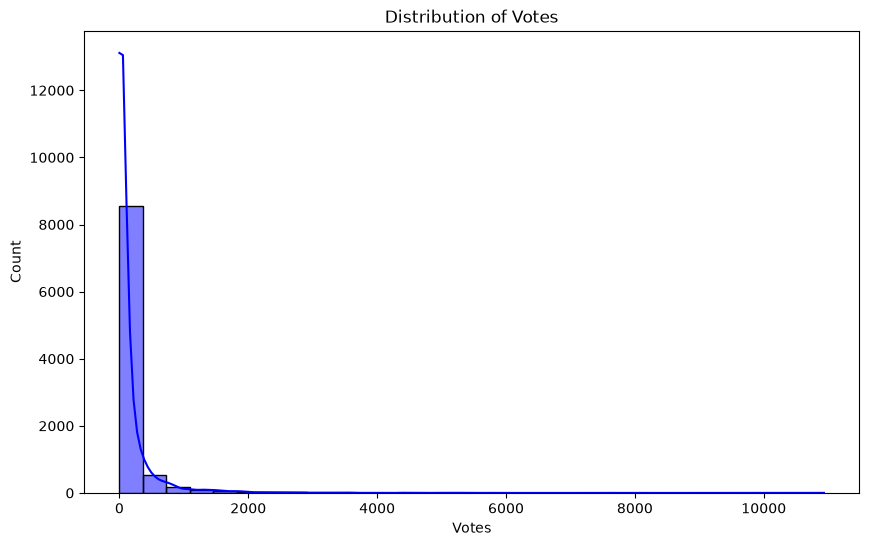

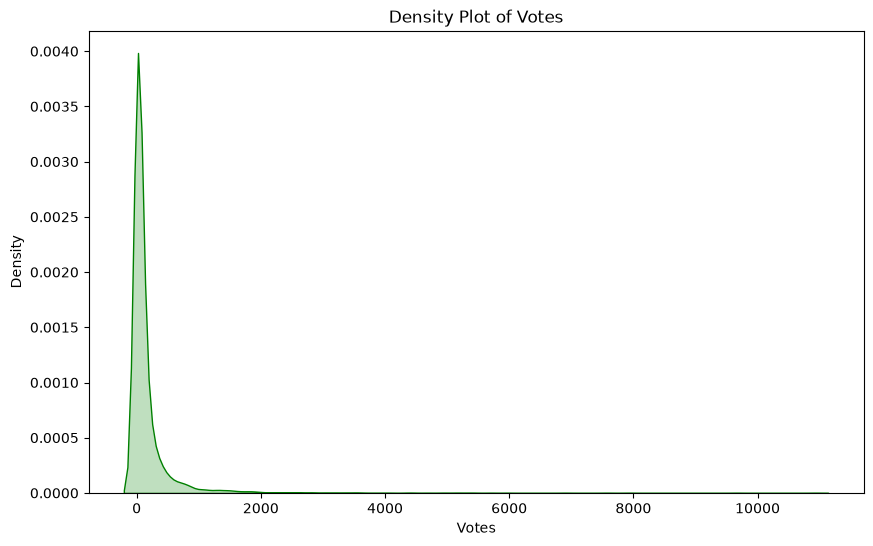

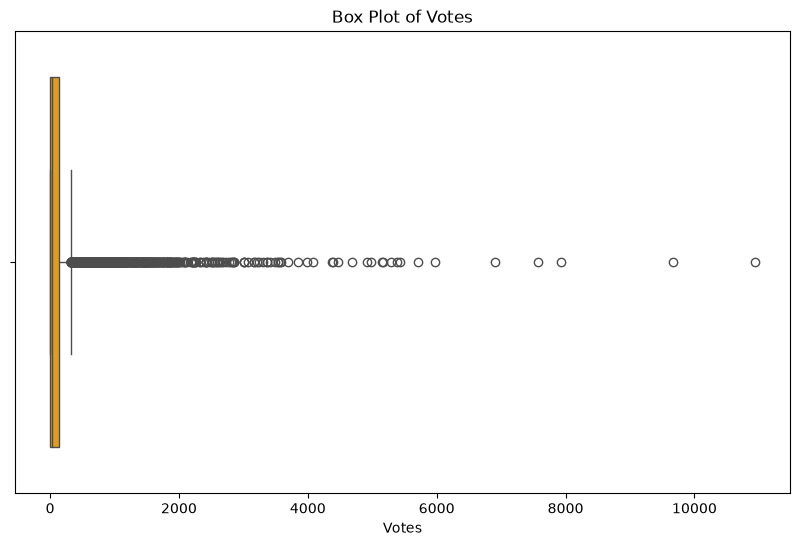

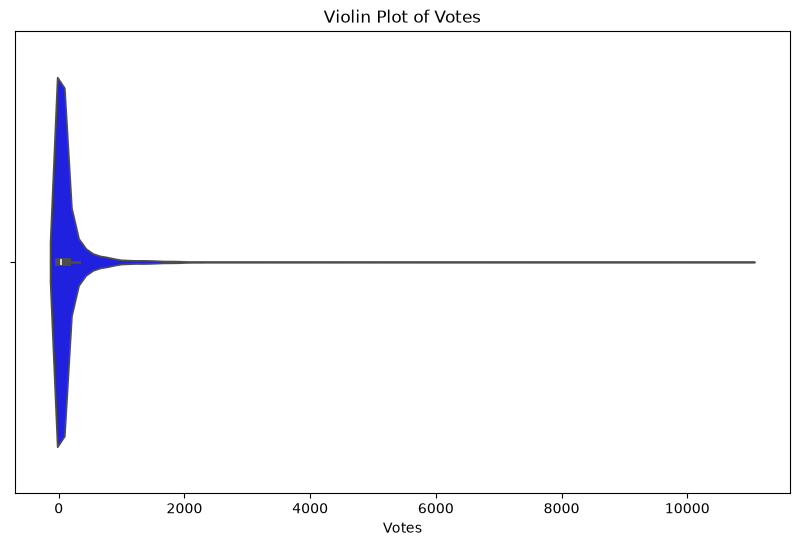

In [54]:
# Votes-Univariate Analysis

votes_mean = df['Votes'].mean()
votes_median = df['Votes'].median()
votes_std = df['Votes'].std()
print(f"Mean: {votes_mean}, Median: {votes_median}, Standard Deviation: {votes_std}")
# outlier using IQR method
Q1_votes=df['Votes'].quantile(0.25)
Q3_votes=df['Votes'].quantile(0.75)
IQR=Q3_votes - Q1_votes

lower_bound_votes = Q1_votes - 1.5 * IQR
upper_bound_votes = Q3_votes + 1.5 * IQR


iqr_outliers_votes = df[(df['Votes'] < lower_bound_votes) | (df['Votes'] > upper_bound_votes)]

print(f"Number of outliers in Votes using IQR method: {len(iqr_outliers_votes)}")

# outlier detection using Z-score method
z_scores_votes = np.abs(stats.zscore(df['Votes']))
z_threshold_votes = 3
z_outliers_votes = np.where(z_scores_votes > z_threshold_votes)
print(f"Number of outliers in Votes using Z-score method: {len(z_outliers_votes[0])}")



# Distribution for the 'Votes' column
plt.figure(figsize=(10,6))
sns.histplot(df['Votes'], bins=30, kde=True, color='blue')
plt.title('Distribution of Votes')

# Density/KDE plot for the 'Votes' column
plt.figure(figsize=(10,6))
sns.kdeplot(df['Votes'], shade=True, color='green')
plt.title('Density Plot of Votes')

# Box Plot for the 'Votes' column
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Votes'], color='orange')
plt.title('Box Plot of Votes')

# Violin Plot for the 'Votes' column
plt.figure(figsize=(10,6))
sns.violinplot(x=df['Votes'], color='blue')
plt.title('Violin Plot of Votes')

Number of restaurants with table booking: 1158
Number of restaurants without table booking: 8393


Text(0.5, 1.0, 'Violin Plot of Aggregate Ratings by Table Booking Status')

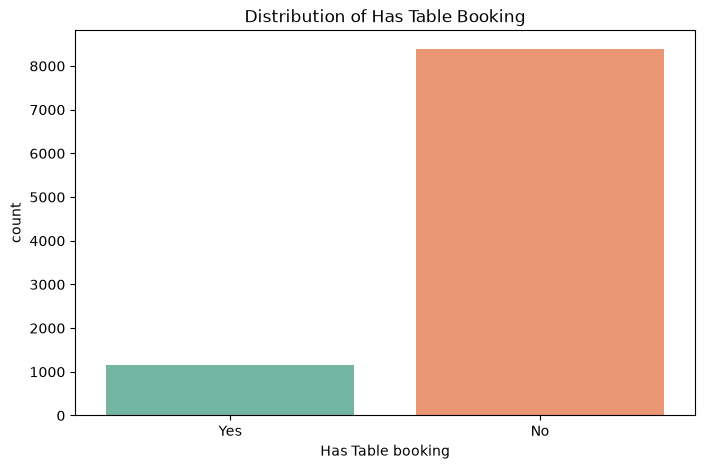

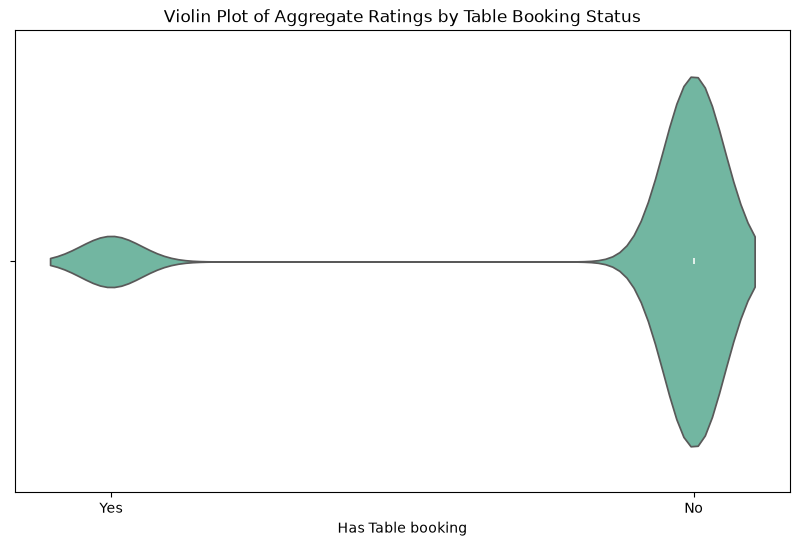

In [55]:
# has table booking or not analysis

yes_response = df['Has Table booking'].value_counts().get('Yes')
no_response = df['Has Table booking'].value_counts().get('No')
print(f"Number of restaurants with table booking: {yes_response}")
print(f"Number of restaurants without table booking: {no_response}")

#Distribution of 'Has Table booking' column
plt.figure(figsize=(8,5))
plt.title('Distribution of Has Table Booking')
sns.countplot(x='Has Table booking', data=df, palette='Set2')

# violin plot for 'Has Table booking' column
plt.figure(figsize=(10,6))
sns.violinplot(x='Has Table booking', data=df, palette='Set2')
plt.title('Violin Plot of Aggregate Ratings by Table Booking Status')


Mean Price Range: 1.804837189823055
Median Price Range: 2.0
Mode Price Range: 1
Standard Deviation of Price Range: 0.905608847397614
Number of outliers in Price Range using IQR method: 586
Number of outliers in Price Range using Z-score method: 0


Text(0.5, 1.0, 'Violin Plot of Price Range')

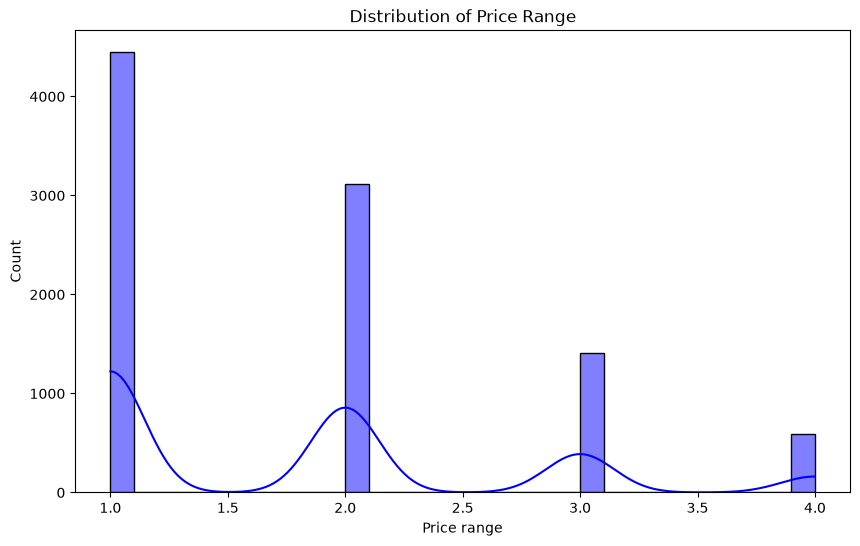

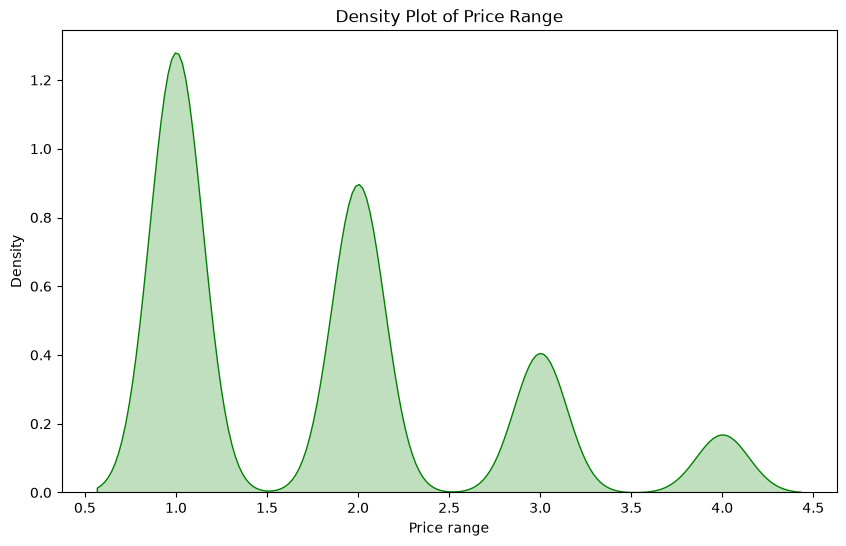

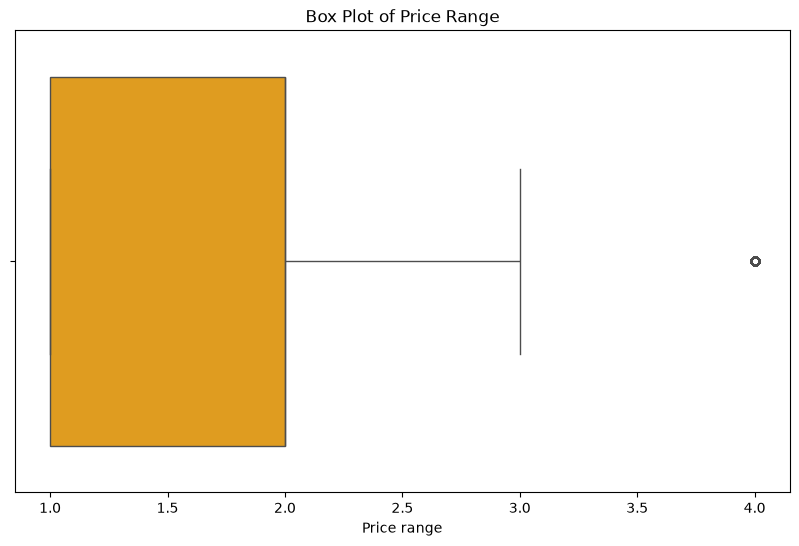

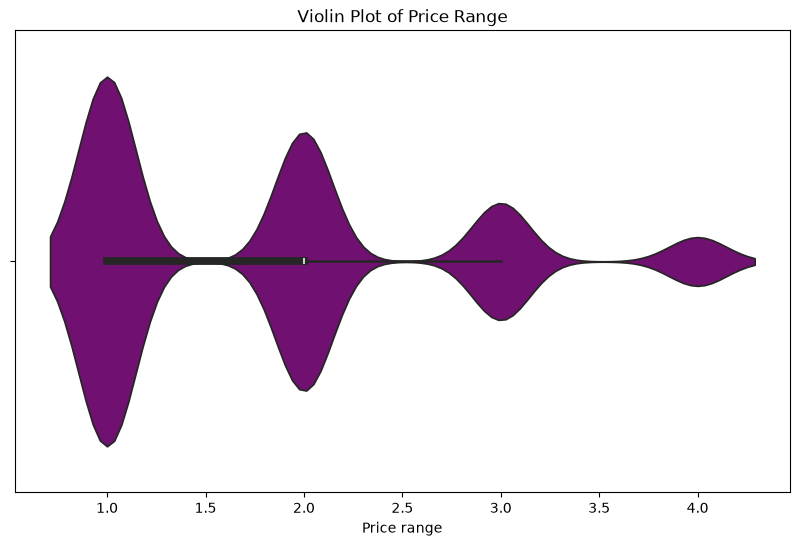

In [56]:
# Price range analysis
mean_price_range = df['Price range'].mean()
median_price_range = df['Price range'].median()
mode_price_range = df['Price range'].mode()[0]
std_price_range = df['Price range'].std()
print(f"Mean Price Range: {mean_price_range}")
print(f"Median Price Range: {median_price_range}")
print(f"Mode Price Range: {mode_price_range}")
print(f"Standard Deviation of Price Range: {std_price_range}")

# Outlier detection for 'Price range' using IQR method
Q1_price = df['Price range'].quantile(0.25)
Q3_price = df['Price range'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price
outliers_price = df[(df['Price range'] < lower_bound_price) | (df['Price range'] > upper_bound_price)]
print(f"Number of outliers in Price Range using IQR method: {len(outliers_price)}")

# outlier detection for 'Price range' using Z-score method
z_scores_price = np.abs(stats.zscore(df['Price range']))
z_threshold_price = 3
z_outliers_price = np.where(z_scores_price > z_threshold_price)
print(f"Number of outliers in Price Range using Z-score method: {len(z_outliers_price[0])}")


# Distribution for the 'Price range' column

plt.figure(figsize=(10,6))
sns.histplot(df['Price range'], bins=30, kde=True, color='blue')
plt.title('Distribution of Price Range')

# Density/KDE plot for the 'Price range' column
plt.figure(figsize=(10,6))
sns.kdeplot(df['Price range'], shade=True, color='green')
plt.title('Density Plot of Price Range')

# Box Plot for the 'Price range' column
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Price range'], color='orange')
plt.title('Box Plot of Price Range')

# Violin Plot for the 'Price range' column
plt.figure(figsize=(10,6))
sns.violinplot(x=df['Price range'], color='purple')
plt.title('Violin Plot of Price Range')


Top 10 Cuisines:
Cuisines
North Indian                      0.098093
North Indian, Chinese             0.053553
Chinese                           0.037099
Fast Food                         0.037099
North Indian, Mughlai             0.035003
Cafe                              0.031335
Bakery                            0.022846
North Indian, Mughlai, Chinese    0.020646
Bakery, Desserts                  0.017816
Street Food                       0.015615
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Top 10 Cuisines Distribution')

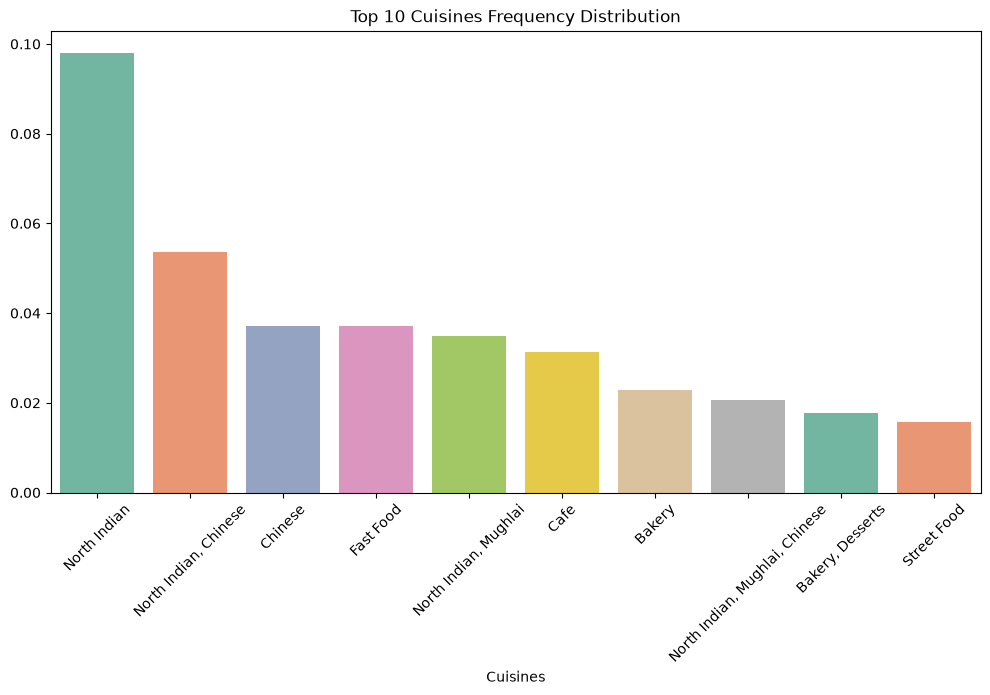

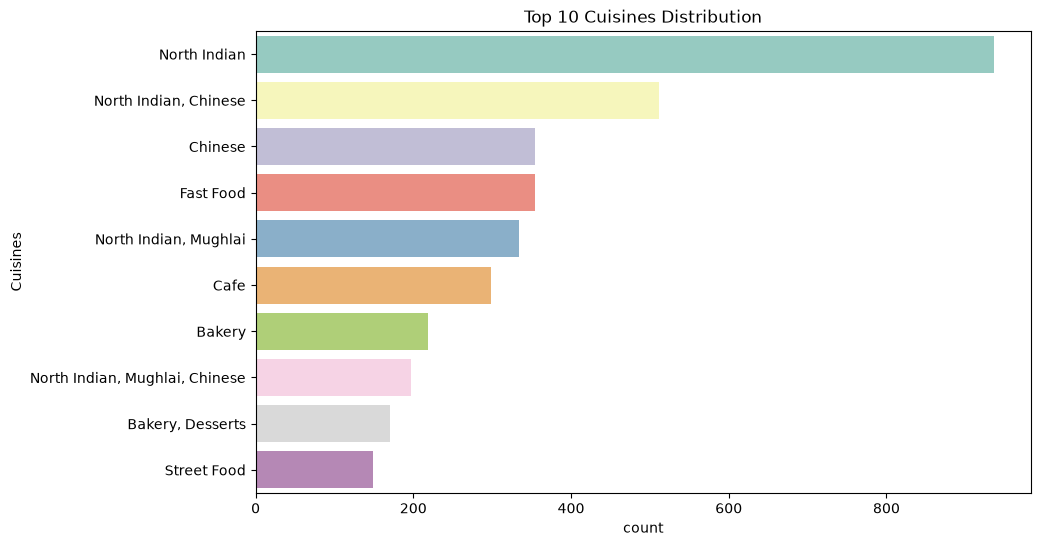

In [57]:
# Cuisine analysis

cuisine_counts = df['Cuisines'].value_counts(10)
print("Top 10 Cuisines:")
print(cuisine_counts.head(10))  

# Frequency distribution of cuisines
plt.figure(figsize=(12,6))
sns.barplot(x=cuisine_counts.head(10).index, y=cuisine_counts.head(10).values, palette='Set2',)
plt.xticks(rotation=45)
plt.title('Top 10 Cuisines Frequency Distribution')

# Distribution of 'Cuisines' column 
plt.figure(figsize=(10,6))
sns.countplot(y='Cuisines', data=df, order=df['Cuisines'].value_counts().iloc[:10].index, palette='Set3')
plt.title('Top 10 Cuisines Distribution')


Mean Average Cost for Two: 1199.2107632708617
Median Average Cost for Two: 400.0
Standard Deviation of Average Cost for Two: 16121.183073499646
Number of outliers in Average Cost for Two using IQR method: 853
Number of outliers in Average Cost for Two using Z-score method: 21


Text(0.5, 1.0, 'Violin Plot of Average Cost for Two')

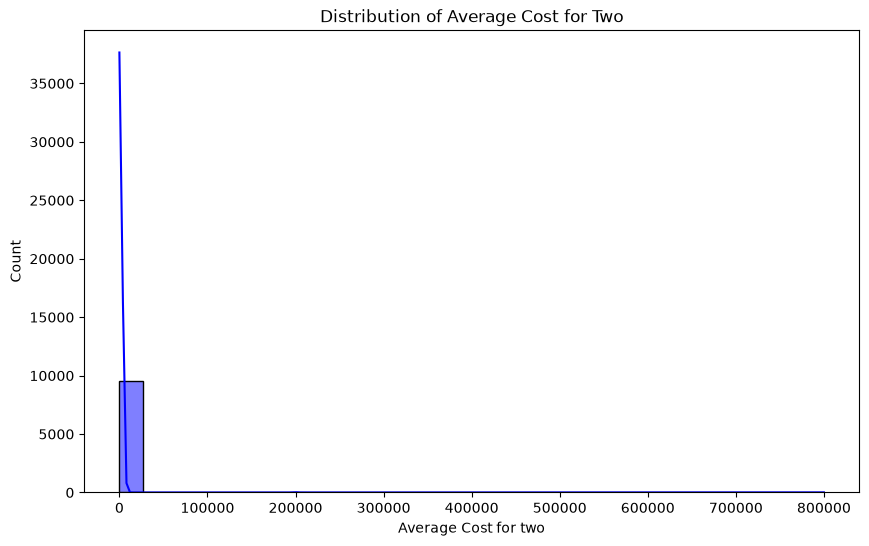

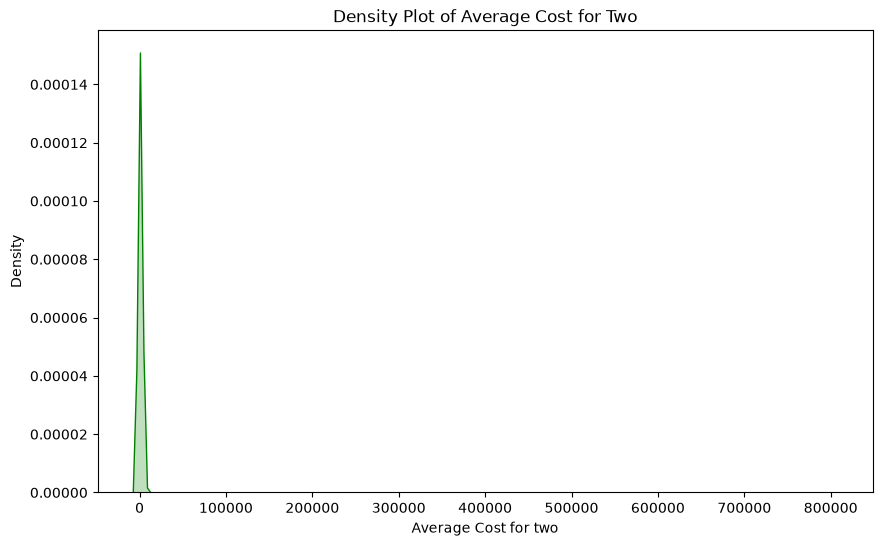

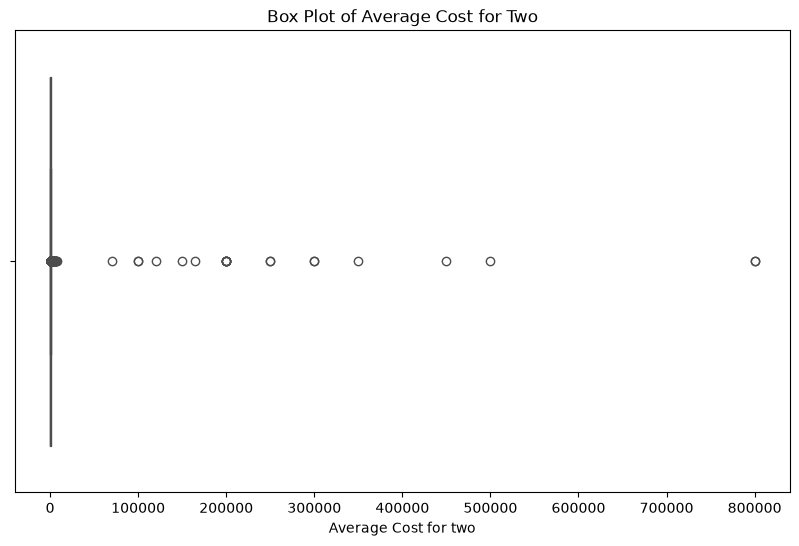

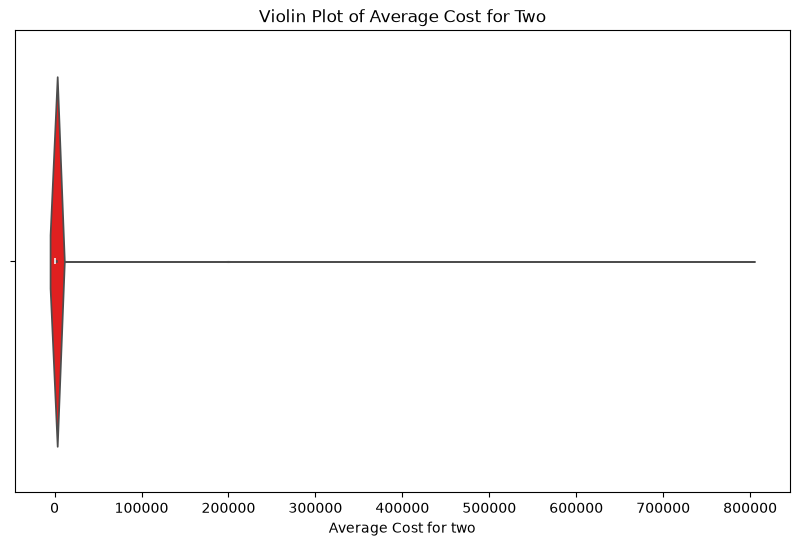

In [58]:
# Average cost of two analysis

mean_avgcost2= df['Average Cost for two'].mean()
median_avgcost2= df['Average Cost for two'].median()
std_avgcost2= df['Average Cost for two'].std()
print(f"Mean Average Cost for Two: {mean_avgcost2}")
print(f"Median Average Cost for Two: {median_avgcost2}")
print(f"Standard Deviation of Average Cost for Two: {std_avgcost2}")

# Outliers detection for 'Average Cost for two' using IQR method
Q1_avgcost2 = df['Average Cost for two'].quantile(0.25)
Q3_avgcost2 = df['Average Cost for two'].quantile(0.75)
IQR_avgcost2 = Q3_avgcost2 - Q1_avgcost2
lower_bound_avgcost2 = Q1_avgcost2 - 1.5 * IQR_avgcost2
upper_bound_avgcost2 = Q3_avgcost2 + 1.5 * IQR_avgcost2

outliers_avgcost2 = df[(df['Average Cost for two'] < lower_bound_avgcost2) | (df['Average Cost for two'] > upper_bound_avgcost2)]
print(f"Number of outliers in Average Cost for Two using IQR method: {len(outliers_avgcost2)}")

# Outlier detection for 'Average Cost for two' using Z-score method
z_scores_avgcost2 = np.abs(stats.zscore(df['Average Cost for two']))
z_threshold_avgcost2 = 3
z_outliers_avgcost2 = np.where(z_scores_avgcost2 > z_threshold_avgcost2)
print(f"Number of outliers in Average Cost for Two using Z-score method: {len(z_outliers_avgcost2[0])}")


# Distribution for the 'Average Cost for two' column
plt.figure(figsize=(10,6))
sns.histplot(df['Average Cost for two'], bins=30, kde=True, color='blue')
plt.title('Distribution of Average Cost for Two')

# Density/KDE plot for the 'Average Cost for two' column
plt.figure(figsize=(10,6))
sns.kdeplot(df['Average Cost for two'], shade=True, color='green')
plt.title('Density Plot of Average Cost for Two')

# Box Plot for the 'Average Cost for two' column
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Average Cost for two'], color='orange')
plt.title('Box Plot of Average Cost for Two')

# Violin Plot for the 'Average Cost for two' column
plt.figure(figsize=(10,6))
sns.violinplot(x=df['Average Cost for two'], color='red')
plt.title('Violin Plot of Average Cost for Two')


Top 10 Cities by Number of Restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64
Minority of Restaurants in Each City:
New Delhi: 5473 restaurants 	 Percentage: 57.30%
Gurgaon: 1118 restaurants 	 Percentage: 11.71%
Noida: 1080 restaurants 	 Percentage: 11.31%
Faridabad: 251 restaurants 	 Percentage: 2.63%
Ghaziabad: 25 restaurants 	 Percentage: 0.26%
Ahmedabad: 21 restaurants 	 Percentage: 0.22%
Amritsar: 21 restaurants 	 Percentage: 0.22%
Bhubaneshwar: 21 restaurants 	 Percentage: 0.22%
Guwahati: 21 restaurants 	 Percentage: 0.22%
Lucknow: 21 restaurants 	 Percentage: 0.22%


Text(0.5, 1.0, 'Top 10 Cities Distribution of Restaurants')

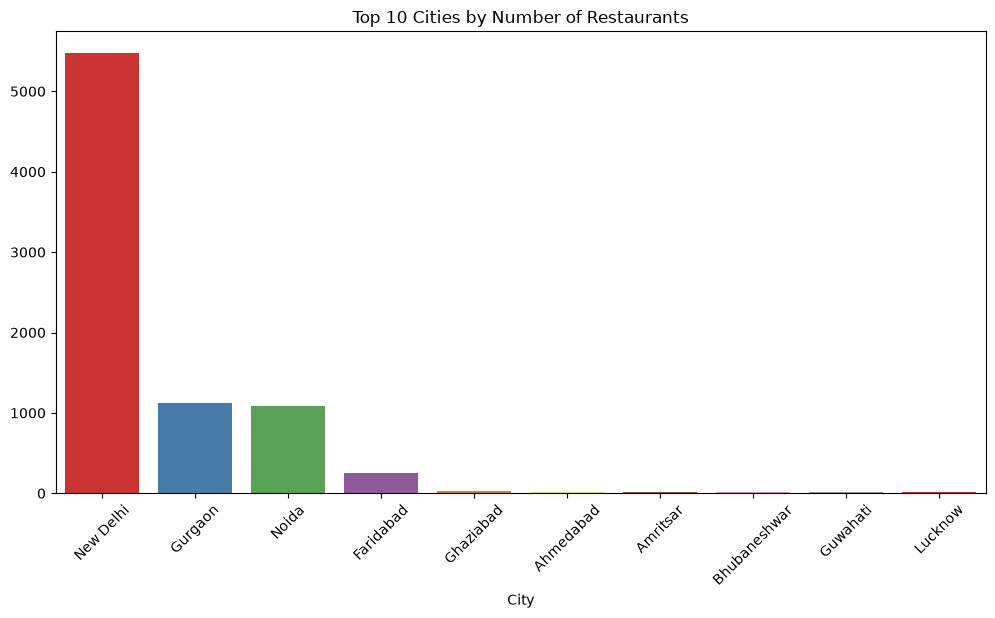

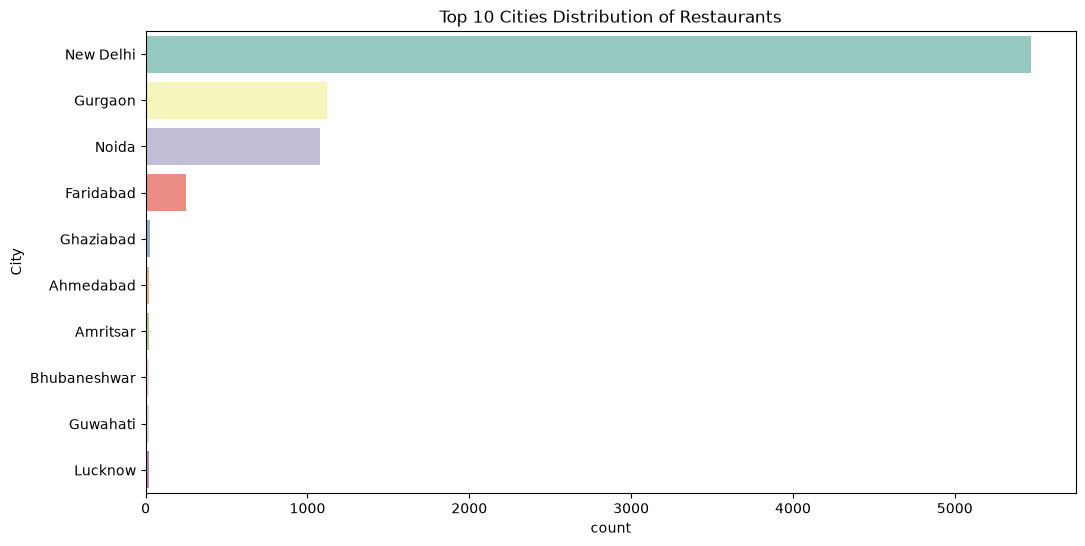

In [59]:
# City analysis
city_counts = df['City'].value_counts()
print("Top 10 Cities by Number of Restaurants:")
print(city_counts.head(10))

minority_city = df['City'].value_counts().iloc[:10].index
print("Minority of Restaurants in Each City:")
for city in minority_city:
    count = df[df['City'] == city].shape[0]
    print(f"{city}: {count} restaurants \t Percentage: {count / df.shape[0] * 100:.2f}%")    


# Distribution of 'City' column
plt.figure(figsize=(12,6))
sns.barplot(x=city_counts.head(10).index, y=city_counts.head(10).values, palette='Set1')
plt.xticks(rotation=45)
plt.title('Top 10 Cities by Number of Restaurants')



# Minority of restaurants in each city
plt.figure(figsize=(12,6))
sns.countplot(y='City', data=df, order=df['City'].value_counts().iloc[:10].index, palette='Set3')
plt.title('Top 10 Cities Distribution of Restaurants')

Number of restaurants with table booking: 1158
Number of restaurants without table booking: 8393


<Axes: title={'center': 'Distribution of Has Table Booking'}, xlabel='Has Table booking', ylabel='count'>

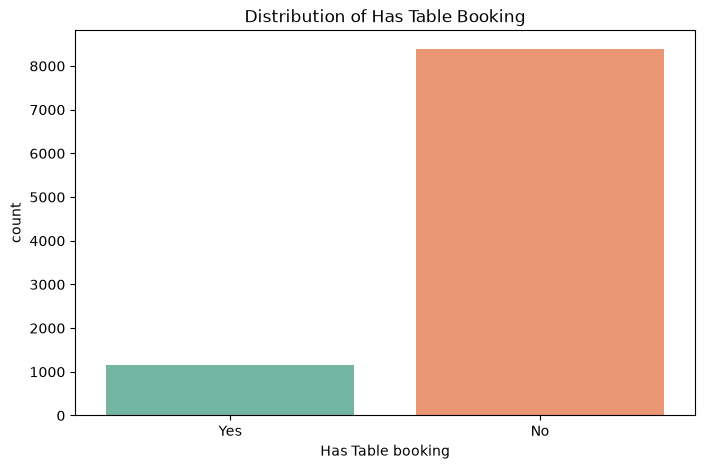

In [60]:
# has table booking or not analysis

yes_response = df['Has Table booking'].value_counts().get('Yes')
no_response = df['Has Table booking'].value_counts().get('No')

print(f"Number of restaurants with table booking: {yes_response}")
print(f"Number of restaurants without table booking: {no_response}")

# Distribution of 'Has Table booking' column
plt.figure(figsize=(8,5))
plt.title('Distribution of Has Table Booking')
sns.countplot(x='Has Table booking', data=df, palette='Set2')



In [61]:
# Rating text analysis
rating_text_counts = df['Rating text'].value_counts()

print(f"Rating Text Counts:{rating_text_counts}")


Rating Text Counts:Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


Currency Counts:Currency
Indian Rupees(Rs.)        8652
Dollar($)                  482
Pounds(��)                  80
Brazilian Real(R$)          60
Emirati Diram(AED)          60
Rand(R)                     60
NewZealand($)               40
Turkish Lira(TL)            34
Botswana Pula(P)            22
Indonesian Rupiah(IDR)      21
Qatari Rial(QR)             20
Sri Lankan Rupee(LKR)       20
Name: count, dtype: int64 	
Locality Counts:Locality
Connaught Place    122
Rajouri Garden      99
Shahdara            87
Defence Colony      86
Malviya Nagar       85
                  ... 
Caddebostan          1
Emirg��n             1
Kad۱k�_y Merkez      1
Ko��uyolu            1
Moda                 1
Name: count, Length: 1208, dtype: int64 	
Country Code Counts:Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64 	
Top 10 Localit

Text(0.5, 1.0, 'Distribution of Country Code')

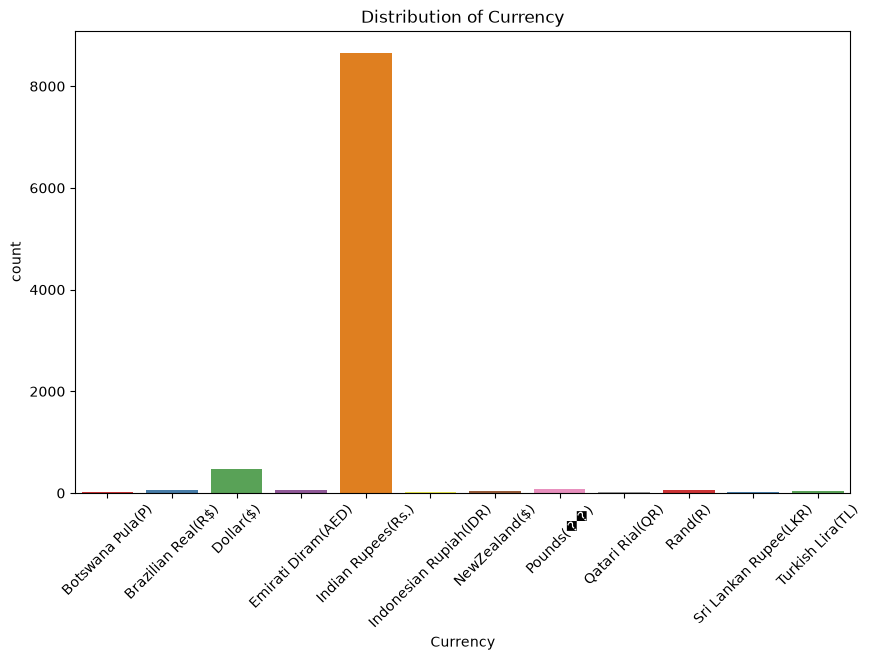

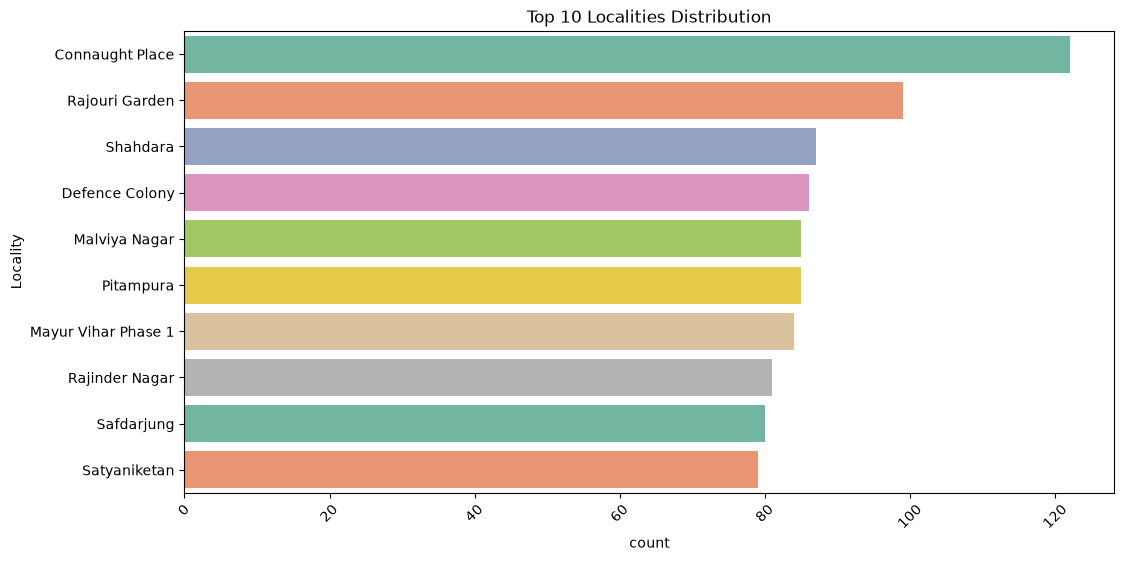

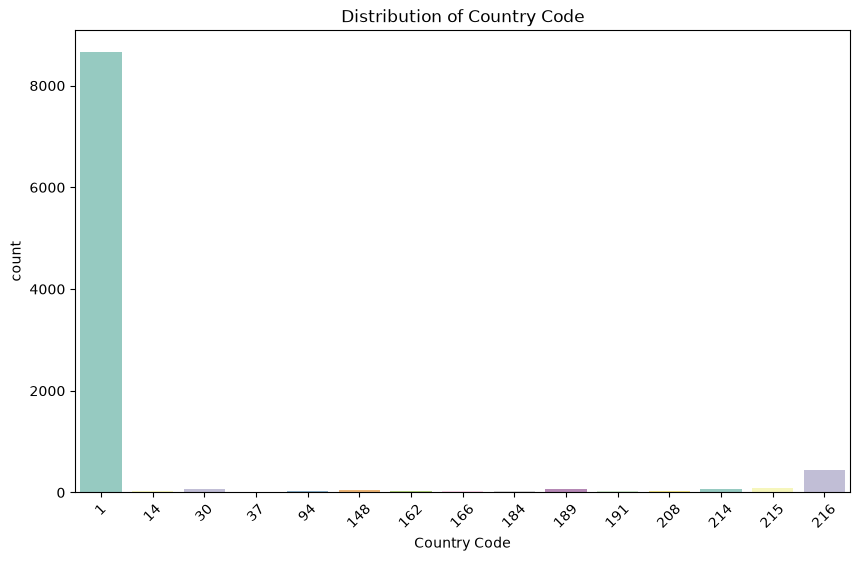

In [62]:
# Currency,locality,Country Code analysis
currency_counts = df['Currency'].value_counts()
locality_counts = df['Locality'].value_counts()
country_code_counts = df['Country Code'].value_counts()

print(f"Currency Counts:{currency_counts} \t")
print(f"Locality Counts:{locality_counts} \t")
print(f"Country Code Counts:{country_code_counts} \t")

print(f"Top 10 Localities by Number of Restaurants:\n{locality_counts.head(10)}")
print(f"Top 10 Country Codes by Number of Restaurants:\n{country_code_counts.head(10)}")
print(f"Top 10 Currencies by Number of Restaurants:\n{currency_counts.head(10)}")

# Distribution of 'Currency' column
plt.figure(figsize=(10,6))
sns.countplot(x='Currency', data=df, palette='Set1')
plt.xticks(rotation=45)
plt.title('Distribution of Currency')

# Distribution of 'Locality' column
plt.figure(figsize=(12,6))
sns.countplot(y='Locality', data=df, order=df['Locality'].value_counts().iloc[:10].index, palette='Set2')
plt.xticks(rotation=45)
plt.title('Top 10 Localities Distribution')

# Distribution of 'Country Code' column
plt.figure(figsize=(10,6))
sns.countplot(x='Country Code', data=df, palette='Set3')
plt.xticks(rotation=45)
plt.title('Distribution of Country Code')

Text(0.5, 1.0, 'Box Plot of Votes by Rating Text')

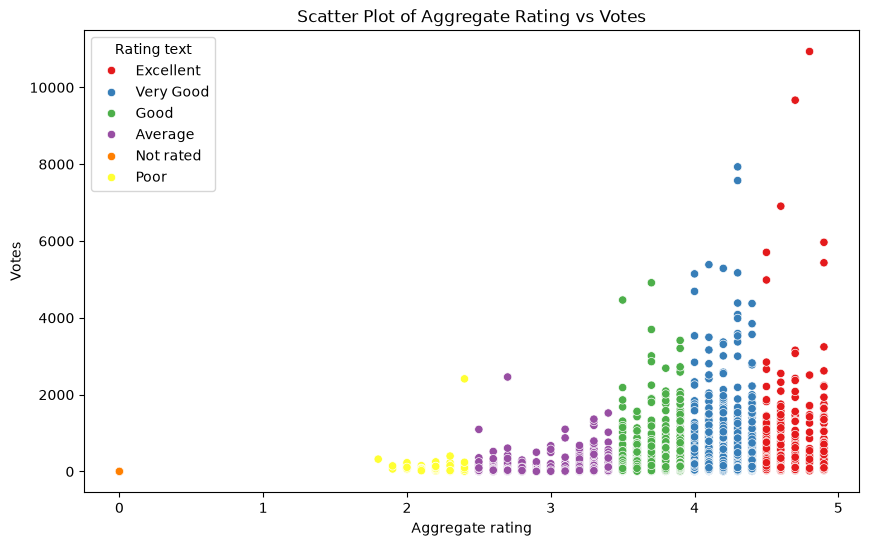

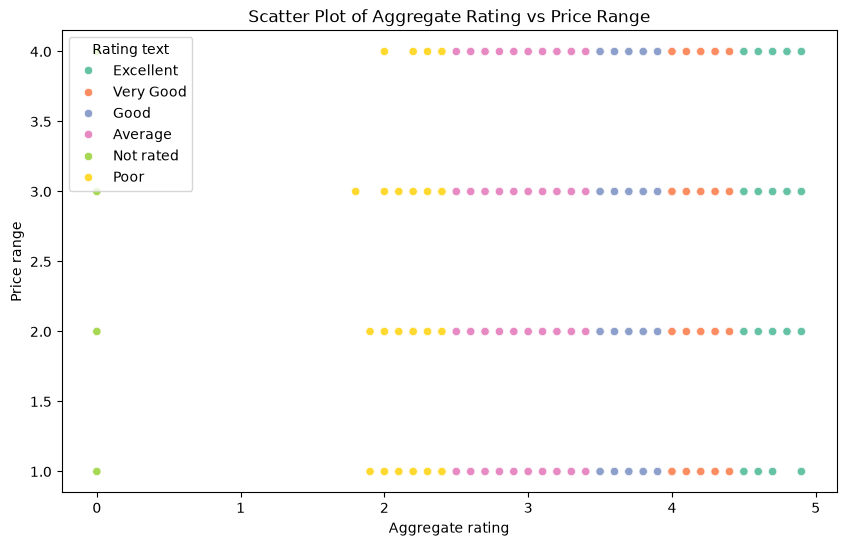

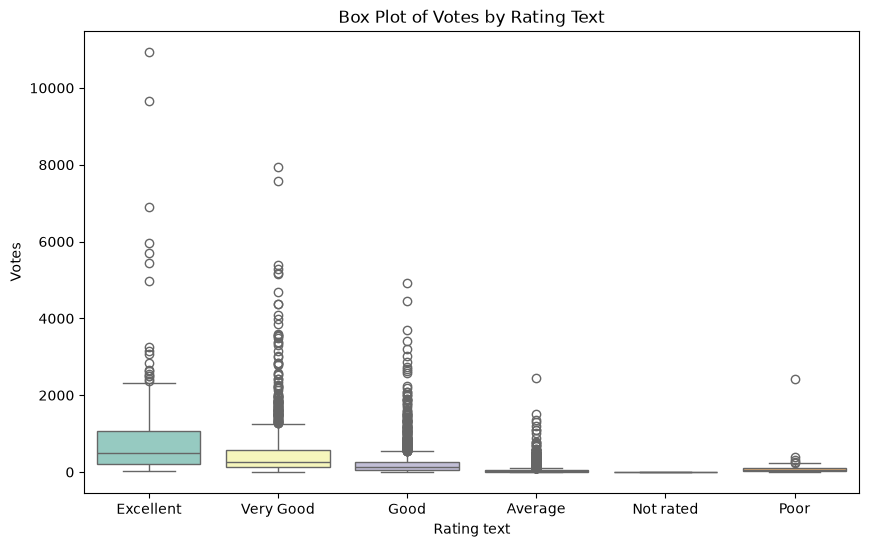

In [63]:
# multivariate analysis between 'Aggregate rating' and 'Votes'
plt.figure(figsize=(10,6))
sns.scatterplot(x='Aggregate rating', y='Votes', data=df, hue='Rating text', palette='Set1')
plt.title('Scatter Plot of Aggregate Rating vs Votes')

# multivariate analysis between 'Aggregate rating' and 'Price range'
plt.figure(figsize=(10,6))
sns.scatterplot(x='Aggregate rating', y='Price range', data=df, hue='Rating text', palette='Set2')
plt.title('Scatter Plot of Aggregate Rating vs Price Range')


# multivariate analysis between 'Votes' and 'Rating text'
plt.figure(figsize=(10,6))
sns.boxplot(x='Rating text', y='Votes', data=df, palette='Set3')
plt.title('Box Plot of Votes by Rating Text')

Text(0.5, 1.0, 'Box Plot of Aggregate Rating by City')

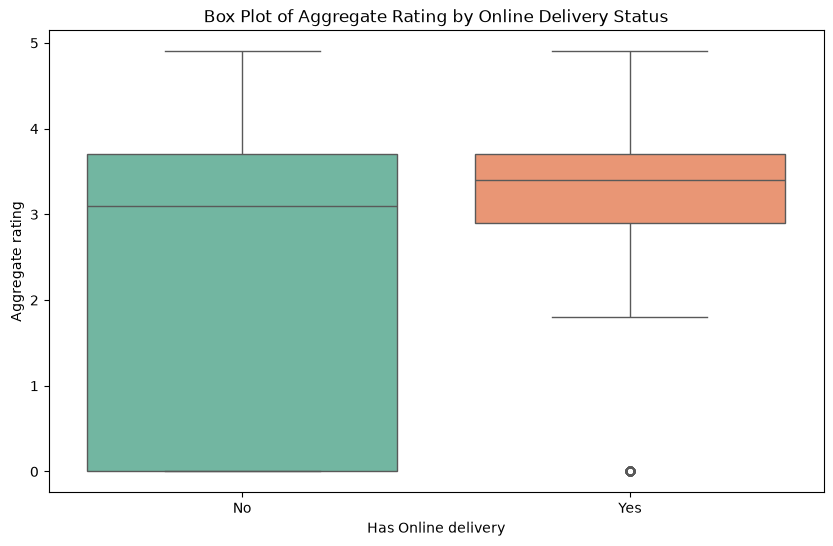

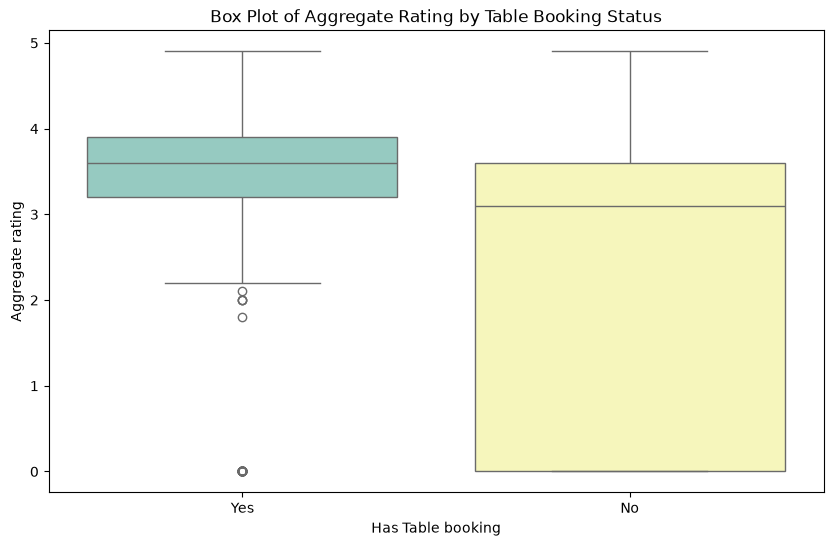

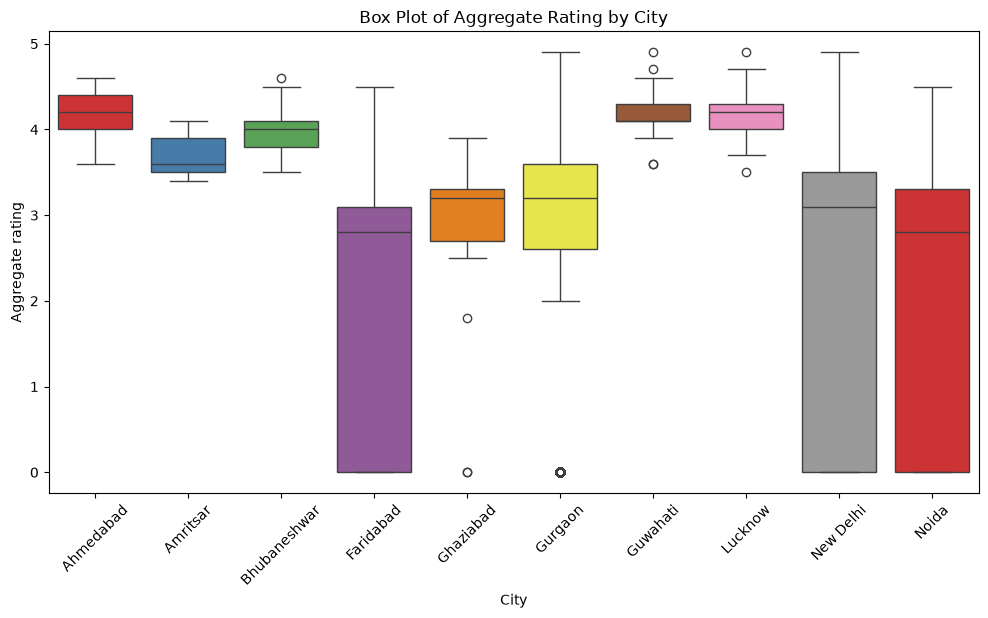

In [64]:
# # Multivariate analysis between 'Cuisines' and 'Aggregate rating'
# cuisine_counts = df['Cuisines'].value_counts(10)
# plt.figure(figsize=(12,6))
# sns.boxplot(x=cuisine_counts, y='Aggregate rating', data=df, palette='Set1')
# plt.xticks(rotation=90)
# plt.title('Box Plot of Aggregate Rating by Cuisines')


# bivariate analysis between 'Aggregate rating' and 'Has Online delivery'
plt.figure(figsize=(10,6))
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=df, palette='Set2')
plt.title('Box Plot of Aggregate Rating by Online Delivery Status')

# bivariate analysis between 'Aggregate rating' and 'Has Table booking'
plt.figure(figsize=(10,6))
sns.boxplot(x='Has Table booking', y='Aggregate rating', data=df, palette='Set3')
plt.title('Box Plot of Aggregate Rating by Table Booking Status')
# bivariate analysis between 'Aggregate rating' and 'city'
plt.figure(figsize=(12,6))
sns.boxplot(x='City', y='Aggregate rating', data=df[df['City'].isin(df['City'].value_counts().head(10).index)], palette='Set1')
plt.xticks(rotation=45)
plt.title('Box Plot of Aggregate Rating by City')

ValueError: Could not interpret value `Aggregate rating` for `x`. Value is a string, but `data` was not passed.

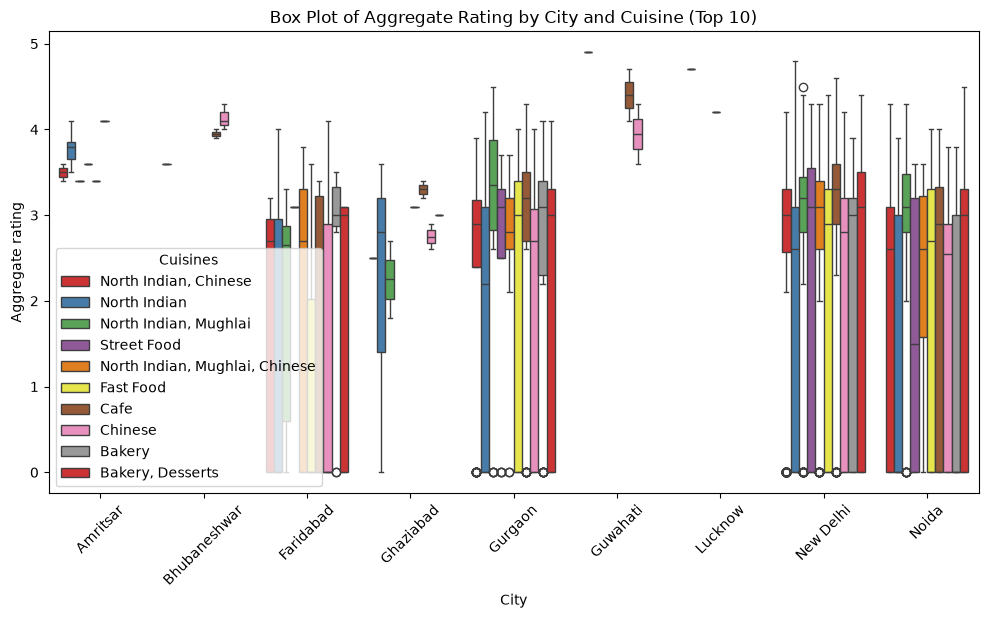

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Multivariate analysis between City + Cuisine + Rating
# Votes + Cost + Rating
# Price Range + Online Delivery + Rating
# Cuisine + Price Range + Rating
# City + Votes + Rating

# Top 10 City + Top 10 Cuisine + Rating in pie chart
plt.figure(figsize=(12,6))
sns.boxplot(x='City', y='Aggregate rating', hue='Cuisines', data=df[df['City'].isin(df['City'].value_counts().head(10).index) & df['Cuisines'].isin(df['Cuisines'].value_counts().head(10).index)], palette='Set1')
plt.xticks(rotation=45)
plt.title('Box Plot of Aggregate Rating by City and Cuisine (Top 10)')

# Votes + Cost + Rating in box plot

plt.figure(figsize=(12,6))
# sns.scatterplot(x='Aggregate rating', y='Votes', hue='Average Cost for two', palette='Set2')
plt.title('Scatter Plot of Votes vs Average Cost for Two colored by Aggregate Rating')

# Pricerange + Online Delivery + Rating in box plot  
plt.figure(figsize=(12,6))
sns.boxplot(x='Price range', y='Aggregate rating', hue='Has Online delivery', data=df, palette='Set3')
plt.title('Box Plot of Aggregate Rating by Price Range and Online Delivery Status')

# Cuisine + Price Range + Rating in box plot
plt.figure(figsize=(12,6))
sns.boxplot(x='Cuisines', y='Aggregate rating', hue='Price range', data=df[df['Cuisines'].isin(df['Cuisines'].value_counts().head(10).index)], palette='Set2')
plt.xticks(rotation=45)
plt.title('Box Plot of Aggregate Rating by Cuisine and Price Range (Top 10 Cuisines)')  

# City + Votes + Rating
plt.figure(figsize=(12,6))
sns.scatterplot(x='Aggregate rating',y='Votes',hue='City',data=df[df['City'].isin(df['City'].value_counts().head(10).index)],palette='Set1',alpha=0.5)
plt.xticks(rotation=90)
plt.title("Boxplot of Rating Votes in top 10 cities")

